In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

In [2]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as psl
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import spearmanr
from matplotlib.patches import Patch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 设置绘图结果
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [3]:
# 1.导入数据
data = pd.read_csv('E:/Data/mcdonalds.csv')
data.head()

,Index,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,1,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,2,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,3,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,4,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,5,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [4]:
# 2.检查数据是否包含缺失值
data.isna().sum()

Index             0
yummy             0
convenient        0
spicy             0
fattening         0
greasy            0
fast              0
cheap             0
tasty             0
expensive         0
healthy           0
disgusting        0
Like              0
Age               0
VisitFrequency    0
Gender            0
dtype: int64

In [5]:
# 3.检查数据是否包含重复值
data.duplicated().sum()

0

In [6]:
# 4.查看数据信息
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Index           1453 non-null   int64 
 1   yummy           1453 non-null   object
 2   convenient      1453 non-null   object
 3   spicy           1453 non-null   object
 4   fattening       1453 non-null   object
 5   greasy          1453 non-null   object
 6   fast            1453 non-null   object
 7   cheap           1453 non-null   object
 8   tasty           1453 non-null   object
 9   expensive       1453 non-null   object
 10  healthy         1453 non-null   object
 11  disgusting      1453 non-null   object
 12  Like            1453 non-null   object
 13  Age             1453 non-null   int64 
 14  VisitFrequency  1453 non-null   object
 15  Gender          1453 non-null   object
dtypes: int64(2), object(14)
memory usage: 181.8+ KB


In [7]:
# 5.排查异常值
# 5.1 object类型
characteristic = data.select_dtypes(include = ['object']).columns.tolist()

for i in characteristic:
    print(f'{i}:')
    print(f'共有:{len(data[i].unique())}条唯一值')
    print(data[i].unique())
    print('-'*75)

yummy:
共有:2条唯一值
['No' 'Yes']
---------------------------------------------------------------------------
convenient:
共有:2条唯一值
['Yes' 'No']
---------------------------------------------------------------------------
spicy:
共有:2条唯一值
['No' 'Yes']
---------------------------------------------------------------------------
fattening:
共有:2条唯一值
['Yes' 'No']
---------------------------------------------------------------------------
greasy:
共有:2条唯一值
['No' 'Yes']
---------------------------------------------------------------------------
fast:
共有:2条唯一值
['Yes' 'No']
---------------------------------------------------------------------------
cheap:
共有:2条唯一值
['Yes' 'No']
---------------------------------------------------------------------------
tasty:
共有:2条唯一值
['No' 'Yes']
---------------------------------------------------------------------------
expensive:
共有:2条唯一值
['Yes' 'No']
---------------------------------------------------------------------------
healthy:
共有:2条唯一值
['No' 'Yes']
-----------

In [8]:
# 5.2 int类型
data.describe()

,Index,Age
count,1453.000000,1453.000000
mean,727.000000,44.604955
std,419.589283,14.221178
min,1.000000,18.000000
25%,364.000000,33.000000
50%,727.000000,45.000000
75%,1090.000000,57.000000
max,1453.000000,71.000000


In [9]:
# 6.数据处理
data['Index'] = data['Index'].astype('str')
data['Like'] = data['Like'].str.extract(r'([+-]?\d+)$').fillna(data['Like'])
data['like_int'] = data['Like'].astype('int')

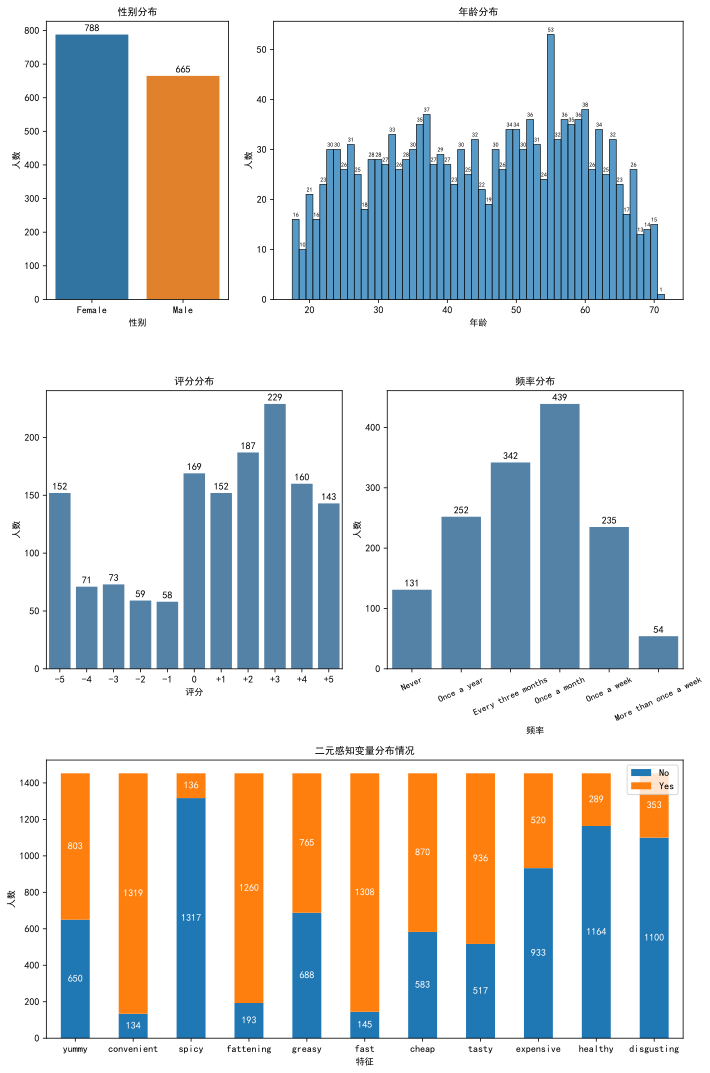

In [10]:
# 7. 数据分布可视化
plt.figure(figsize = (10, 15))

# 7.1性别分布
ax_Gender = plt.subplot2grid((3, 6), (0, 0), colspan = 2)
sns.countplot(x = 'Gender', data = data, ax = ax_Gender)

ax_Gender.set_title('性别分布', fontsize = 10, fontweight = 'bold')
ax_Gender.set_xlabel('性别', fontsize = 9)
ax_Gender.set_ylabel('人数', fontsize = 9)
ax_Gender.grid(False)

for container in ax_Gender.containers:
    ax_Gender.bar_label(container, label_type = 'edge', fontsize = 10, padding = 2)
    
# 7.2年龄分布
ax_Age = plt.subplot2grid((3, 6), (0, 2), colspan = 4)
sns.histplot(data['Age'], discrete = True, ax = ax_Age, kde = False)

ax_Age.set_title('年龄分布', fontsize = 10, fontweight = 'bold')
ax_Age.set_xlabel('年龄', fontsize = 9)
ax_Age.set_ylabel('人数', fontsize = 9)
ax_Age.grid(False)

for container in ax_Age.containers:
    ax_Age.bar_label(container, label_type = 'edge', fontsize = 6, padding = 2)
    
# 7.3喜好分布
ax_Like = plt.subplot2grid((3, 6), (1, 0), colspan = 3)
like_order = ['-5', '-4', '-3', '-2', '-1', '0', '+1', '+2', '+3', '+4', '+5']
sns.countplot(x = 'Like', data = data, order = like_order, color = '#4682B4', ax = ax_Like)

ax_Like.set_title('评分分布', fontsize = 10, fontweight = 'bold')
ax_Like.set_xlabel('评分', fontsize = 9)
ax_Like.set_ylabel('人数', fontsize = 9)
ax_Like.grid(False)

for container in ax_Like.containers:
    ax_Like.bar_label(container, label_type = 'edge', fontsize = 10, padding = 2)
    
# 7.4频率分布
ax_VisitFrequency = plt.subplot2grid((3, 6), (1, 3), colspan = 3)
visitFrequency_order = ['Never', 'Once a year', 'Every three months', 
                        'Once a month', 'Once a week', 'More than once a week']
sns.countplot(x = 'VisitFrequency', data = data, order = visitFrequency_order, color = '#4682B4', ax = ax_VisitFrequency)

ax_VisitFrequency.set_title('频率分布', fontsize = 10, fontweight = 'bold')
ax_VisitFrequency.set_xlabel('频率', fontsize = 9)
ax_VisitFrequency.set_ylabel('人数', fontsize = 9)
ax_VisitFrequency.tick_params(axis = 'x', rotation = 25, labelsize = 9)

for container in ax_VisitFrequency.containers:
    ax_VisitFrequency.bar_label(container, label_type = 'edge', fontsize = 10, padding=2)
    
# 7.5特征分布
ax_characteristic = plt.subplot2grid((3, 6), (2, 0), colspan = 6)
yes_no_vars = ['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 
               'cheap', 'tasty', 'expensive', 'healthy', 'disgusting']

# 计算每个分类变量的频数
yes_no_counts = data[yes_no_vars].apply(lambda x: x.value_counts())
yes_no_counts = yes_no_counts.transpose()

# 绘制堆叠条形图stacked=True
bar_plot = yes_no_counts.plot(kind = 'bar', stacked = True, ax = ax_characteristic, color = ['#1f77b4', '#ff7f0e'], grid = False)
ax_characteristic.set_title('二元感知变量分布情况', fontsize = 10, fontweight = 'bold')
ax_characteristic.set_xlabel('特征', fontsize = 9)
ax_characteristic.set_ylabel('人数', fontsize = 9)
ax_characteristic.legend(loc = 'upper right')
plt.xticks(rotation = 0)

# 在每个颜色段上标注数量
for i, category in enumerate(yes_no_counts.index):
    y_offset = 0
    for item, count in yes_no_counts.loc[category].items():
        if count > 0:
            bar_plot.text(i, y_offset + count / 2, f'{count}', ha = 'center', va = 'center', 
                          fontsize = 10, color = 'white', fontweight = 'bold')
        y_offset += count

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/现状可视化1.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

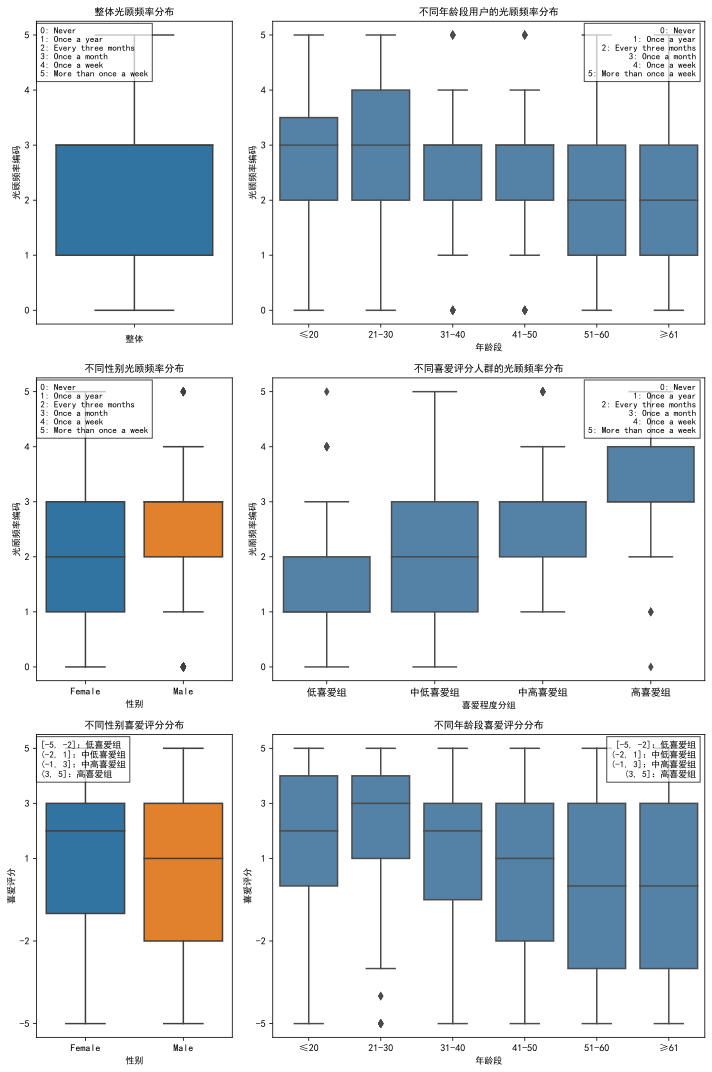

In [11]:
# 建立有序映射字典
freq_map = {
    'Never': 0,
    'Once a year': 1,
    'Every three months': 2,
    'Once a month': 3,
    'Once a week': 4,
    'More than once a week': 5
}
data['freq_code'] = data['VisitFrequency'].map(freq_map)

# 映射说明
freq_text = """0: Never
1: Once a year
2: Every three months
3: Once a month
4: Once a week
5: More than once a week"""

like_text = """[-5, -2]：低喜爱组
(-2, 1]：中低喜爱组
(-1, 3]：中高喜爱组
(3, 5]：高喜爱组"""

plt.figure(figsize = (10, 15))

# 7.6整体光顾频率
ax_freq_box = plt.subplot2grid((3, 3), (0, 0), colspan = 1)
sns.boxplot(y = 'freq_code', data = data, ax = ax_freq_box)
ax_freq_box.set_yticks([0, 1, 2, 3, 4, 5])

ax_freq_box.set_yticklabels(['0', '1', '2', '3', '4', '5'])
ax_freq_box.set_title('整体光顾频率分布', fontsize = 10, fontweight = 'bold')
ax_freq_box.set_ylabel('光顾频率编码', fontsize = 9)
ax_freq_box.set_xlabel('整体', fontsize = 9)
ax_freq_box.grid(False)

ax_freq_box.text(0.02, 0.98, freq_text, transform = ax_freq_box.transAxes, verticalalignment = 'top',
                 horizontalalignment = 'left', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

# 7.7不同年龄段光顾频率差异
ax_age_freq_box = plt.subplot2grid((3, 3), (0, 1), colspan = 2)

age_bins = [0, 20, 30, 40, 50, 60, 75]
age_labels = ['≤20', '21-30', '31-40', '41-50', '51-60', '≥61']
data['Age_Group'] = pd.cut(data['Age'], bins = age_bins, labels = age_labels, right = True)
ax_age_freq_box.set_yticks([0, 1, 2, 3, 4, 5])

ax_age_freq_box.set_yticklabels(['0', '1', '2', '3', '4', '5'])
sns.boxplot(x = 'Age_Group', y = 'freq_code', data = data, ax = ax_age_freq_box, color = '#4682B4')
ax_age_freq_box.set_title('不同年龄段用户的光顾频率分布', fontsize = 10, fontweight = 'bold')
ax_age_freq_box.set_xlabel('年龄段', fontsize = 9)
ax_age_freq_box.set_ylabel('光顾频率编码', fontsize = 9)
plt.setp(ax_age_freq_box.get_xticklabels(), ha = "center")
ax_age_freq_box.grid(False)

ax_age_freq_box.text(0.98, 0.98, freq_text, transform = ax_age_freq_box.transAxes, verticalalignment = 'top', 
                     horizontalalignment = 'right', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

# 7.8不同性别光顾频率差异
ax_gender_freq_box = plt.subplot2grid((3, 3), (1, 0), colspan = 1)
ax_gender_freq_box.set_yticks([0, 1, 2, 3, 4, 5])

ax_gender_freq_box.set_yticklabels(['0', '1', '2', '3', '4', '5'])
sns.boxplot(x = 'Gender', y = 'freq_code', data = data,  ax = ax_gender_freq_box)
ax_gender_freq_box.set_title('不同性别光顾频率分布', fontsize = 10, fontweight = 'bold')
ax_gender_freq_box.set_xlabel('性别', fontsize = 9)
ax_gender_freq_box.set_ylabel('光顾频率编码', fontsize = 9)
ax_gender_freq_box.grid(False)

ax_gender_freq_box.text(0.02, 0.98, freq_text, transform = ax_gender_freq_box.transAxes, verticalalignment = 'top', 
                        horizontalalignment = 'left', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

# 7.9不同喜爱评分光顾频率差异
ax_like_freq_box = plt.subplot2grid((3, 3), (1, 1), colspan = 2)

like_bins = [-5, -2, 1, 3, 5]
like_labels = ['低喜爱组', '中低喜爱组', '中高喜爱组', '高喜爱组']
data['Like_Group'] = pd.cut(data['like_int'], bins = like_bins, labels = like_labels, right=True)
ax_like_freq_box.set_yticks([0, 1, 2, 3, 4, 5])

ax_like_freq_box.set_yticklabels(['0', '1', '2', '3', '4', '5'])
sns.boxplot(x = 'Like_Group', y = 'freq_code', data = data, ax = ax_like_freq_box, color = "#4682B4")
ax_like_freq_box.set_title('不同喜爱评分人群的光顾频率分布', fontsize = 10, fontweight = 'bold')
ax_like_freq_box.set_xlabel('喜爱程度分组', fontsize = 9)
ax_like_freq_box.set_ylabel('光顾频率编码', fontsize = 9)
ax_like_freq_box.grid(False)

ax_like_freq_box.text(0.98, 0.98, freq_text, transform = ax_like_freq_box.transAxes, verticalalignment = 'top', 
                        horizontalalignment = 'right', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

# 7.10不同性别喜爱程度差异
ax_gender_like_box = plt.subplot2grid((3, 3), (2, 0), colspan = 1)
sns.boxplot(x = 'Gender', y = 'like_int', data = data, ax = ax_gender_like_box)
ax_gender_like_box.set_yticks([-5,-2,1,3,5])

ax_gender_like_box.set_yticklabels(['-5', '-2', '1', '3', '5'])
ax_gender_like_box.set_title('不同性别喜爱评分分布', fontsize = 10, fontweight = 'bold')
ax_gender_like_box.set_xlabel('性别', fontsize = 9)
ax_gender_like_box.set_ylabel('喜爱评分', fontsize = 9)
plt.setp(ax_gender_like_box.get_xticklabels(), ha = "center")
ax_gender_like_box.grid(False)

ax_gender_like_box.text(0.02, 0.98, like_text, transform = ax_gender_like_box.transAxes, verticalalignment = 'top', 
                        horizontalalignment = 'left', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

# 7.11不同年龄段喜爱程度差异
ax_age_like_box = plt.subplot2grid((3, 3), (2, 1), colspan = 2)
sns.boxplot(x = 'Age_Group', y = 'like_int', data = data, ax = ax_age_like_box, color="#4682B4")
ax_age_like_box.set_yticks([-5,-2,1,3,5])

ax_age_like_box.set_yticklabels(['-5', '-2', '1', '3', '5'])
ax_age_like_box.set_title('不同年龄段喜爱评分分布', fontsize = 10, fontweight = 'bold')
ax_age_like_box.set_xlabel('年龄段', fontsize = 9)
ax_age_like_box.set_ylabel('喜爱评分', fontsize = 9)
plt.setp(ax_age_like_box.get_xticklabels(), ha = "center")
ax_age_like_box.grid(False)

ax_age_like_box.text(0.98, 0.98, like_text, transform = ax_age_like_box.transAxes, verticalalignment = 'top', 
                        horizontalalignment = 'right', fontsize = 9, bbox = dict(facecolor = 'white', alpha = 0.7))

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/现状可视化2.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

            变量   相关系数      p值   显著性
0        yummy  0.692  0.0000   ***
7        tasty  0.628  0.0000   ***
1   convenient  0.316  0.0000   ***
9      healthy  0.296  0.0000   ***
5         fast  0.160  0.0000   ***
6        cheap  0.147  0.0000   ***
2        spicy -0.013  0.6212  n.s.
8    expensive -0.126  0.0000   ***
3    fattening -0.174  0.0000   ***
4       greasy -0.253  0.0000   ***
10  disgusting -0.530  0.0000   ***


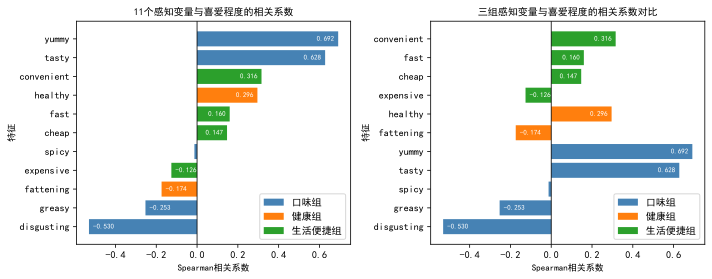

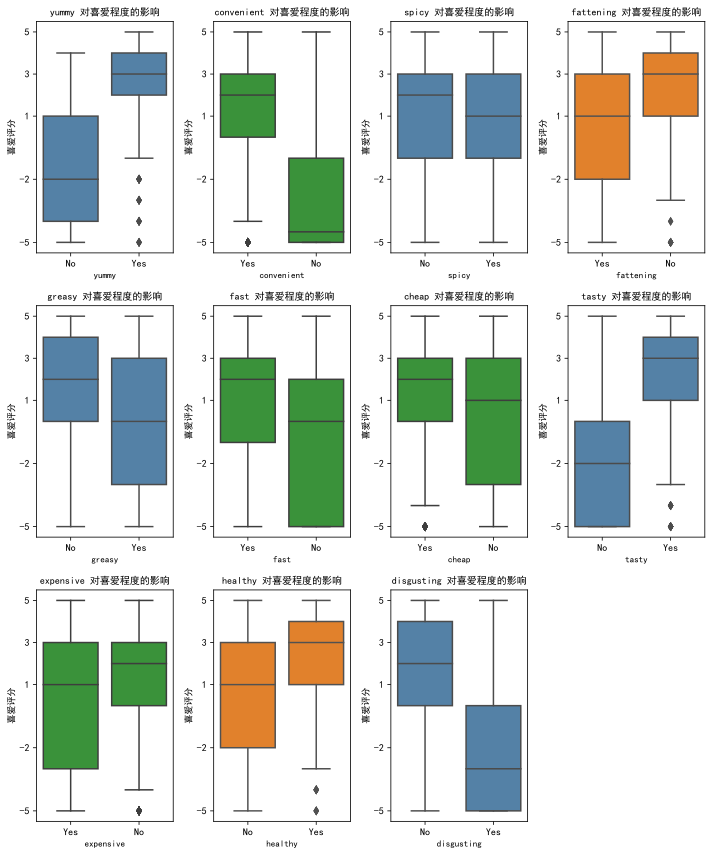

In [12]:
# 将 Yes/No 转为 1/0
for var in yes_no_vars:
    data[var + '_bin'] = data[var].map({'Yes': 1, 'No': 0})

# 分组定义
taste_vars = ['yummy_bin', 'spicy_bin', 'greasy_bin', 'tasty_bin', 'disgusting_bin']
health_vars = ['fattening_bin', 'healthy_bin']
life_vars = ['convenient_bin', 'fast_bin', 'cheap_bin', 'expensive_bin']

# 计算 Spearman 相关系数
corr_results = []
for var in yes_no_vars:
    r, p = spearmanr(data[var + '_bin'], data['like_int'])
    corr_results.append({
        '变量': var,
        '相关系数': round(r, 3),
        'p值': round(p, 4),
        '显著性': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    })

corr_df = pd.DataFrame(corr_results).sort_values('相关系数', ascending = False)
print(corr_df)

# 分组映射
group_map = {
    '口味组': taste_vars,
    '健康组': health_vars,
    '生活便捷组': life_vars
}
group_colors = {'口味组': '#4682B4', '健康组': '#ff7f0e', '生活便捷组': '#2ca02c'}
var2group = {v.replace('_bin', ''): g for g, vs in group_map.items() for v in vs}

plt.figure(figsize=(10, 4))

# 相关系数筛查
ax_corr = plt.subplot2grid((1, 2), (0, 0))

corr_df_sorted = corr_df.sort_values('相关系数', ascending = True)
colors1 = [group_colors[var2group[v]] for v in corr_df_sorted['变量']]
bars1 = ax_corr.barh(corr_df_sorted['变量'], corr_df_sorted['相关系数'], color = colors1)

ax_corr.set_title('11个感知变量与喜爱程度的相关系数', fontsize = 10, fontweight = 'bold')
ax_corr.set_xlabel('Spearman相关系数', fontsize = 9)
ax_corr.set_ylabel('特征', fontsize = 9)
ax_corr.axvline(0, color = 'black', linewidth = 0.8)
ax_corr.grid(False)

for bar, val in zip(bars1, corr_df_sorted['相关系数']):
    offset = 0.02 if val >= 0 else -0.02
    ax_corr.text(val - offset, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va = 'center',
                 ha = 'right' if val >= 0 else 'left',
                 fontsize = 7, fontweight = 'bold', color = 'white')

legend_elements = [Patch(facecolor = group_colors[g], label = g) for g in group_map.keys()]
ax_corr.legend(handles = legend_elements, loc = 'lower right')

# 分组相关系数对比
ax_group_corr = plt.subplot2grid((1, 2), (0, 1))

group_corr = []
for group_name, vars_list in group_map.items():
    for var in vars_list:
        r, p = spearmanr(data[var], data['like_int'])
        group_corr.append({
            '组别': group_name,
            '变量': var.replace('_bin', ''),
            '相关系数': round(r, 3),
            'p值': round(p, 4)
        })

group_corr_df = pd.DataFrame(group_corr)

# 按组别顺序 + 组内相关系数排序
group_order = ['口味组', '健康组', '生活便捷组']
plot_df = pd.concat([
    group_corr_df[group_corr_df['组别'] == g].sort_values('相关系数', ascending = True)
    for g in group_order
]).reset_index(drop=True)

colors2 = [group_colors[g] for g in plot_df['组别']]
bars2 = ax_group_corr.barh(plot_df['变量'], plot_df['相关系数'], color = colors2)

ax_group_corr.set_title('三组感知变量与喜爱程度的相关系数对比', fontsize = 10, fontweight = 'bold')
ax_group_corr.set_xlabel('Spearman相关系数', fontsize = 9)
ax_group_corr.set_ylabel('特征', fontsize = 9)
ax_group_corr.axvline(0, color = 'black', linewidth = 0.8)
ax_group_corr.grid(False)

for bar, val in zip(bars2, plot_df['相关系数']):
    offset = 0.02 if val >= 0 else -0.02
    ax_group_corr.text(val - offset, bar.get_y() + bar.get_height() / 2,
                       f'{val:.3f}', va = 'center',
                       ha = 'right' if val >= 0 else 'left',
                       fontsize = 7, fontweight = 'bold', color = 'white')

ax_group_corr.legend(handles = legend_elements, loc = 'lower right')

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/感知变量与喜爱程度的相关系数.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

# 各感知变量 Yes/No 分组的喜爱程度箱线图
plt.figure(figsize = (10, 12))

for i, var in enumerate(yes_no_vars):
    row, col = i // 4, i % 4
    ax = plt.subplot2grid((3, 4), (row, col))
    
    sns.boxplot(x = var, y = 'like_int', data = data, ax = ax, color = group_colors[var2group[var]])
    ax.set_title(f'{var} 对喜爱程度的影响', fontsize = 10, fontweight = 'bold')
    ax.set_xlabel(var, fontsize = 9)
    ax.set_ylabel('喜爱评分', fontsize = 9)
    ax.set_yticks([-5, -2, 1, 3, 5])
    ax.set_yticklabels(['-5', '-2', '1', '3', '5'])
    ax.grid(False)

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/各感知变量对喜爱程度的影响.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

In [13]:
# PCA主成分分析
# 1. 提取11个产品评价变量
features = ['yummy_bin', 'convenient_bin', 'spicy_bin', 'fattening_bin', 'greasy_bin', 'fast_bin', 
            'cheap_bin', 'tasty_bin', 'expensive_bin', 'healthy_bin', 'disgusting_bin']
X = data[features]
X.head()

,yummy_bin,convenient_bin,spicy_bin,fattening_bin,greasy_bin,fast_bin,cheap_bin,tasty_bin,expensive_bin,healthy_bin,disgusting_bin
0,0,1,0,1,0,1,1,0,1,0,0
1,1,1,0,1,1,1,1,1,1,0,0
2,0,1,1,1,1,1,0,1,1,1,0
3,1,1,0,1,1,1,1,1,0,0,1
4,0,1,0,1,1,1,1,0,0,1,0


In [14]:
# 2. 标准化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 转为DataFrame，方便查看
X_std = pd.DataFrame(X_std, columns=features)
X_std.head()

,yummy_bin,convenient_bin,spicy_bin,fattening_bin,greasy_bin,fast_bin,cheap_bin,tasty_bin,expensive_bin,healthy_bin,disgusting_bin
0,-1.111479,0.318735,-0.321349,0.391375,-1.054476,0.332951,0.818605,-1.345528,1.339489,-0.498279,-0.566488
1,0.899702,0.318735,-0.321349,0.391375,0.948339,0.332951,0.818605,0.743203,1.339489,-0.498279,-0.566488
2,-1.111479,0.318735,3.111884,0.391375,0.948339,0.332951,-1.221590,0.743203,1.339489,2.006908,-0.566488
3,0.899702,0.318735,-0.321349,0.391375,0.948339,0.332951,0.818605,0.743203,-0.746553,-0.498279,1.765261
4,-1.111479,0.318735,-0.321349,0.391375,0.948339,0.332951,0.818605,-1.345528,-0.746553,2.006908,-0.566488


In [15]:
# 3. PCA解释方差
pca = PCA()
X_pca = pca.fit_transform(X_std)

variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(variance)

result = pd.DataFrame({
    "主成分": [f"PC{i}" for i in range(1,12)],
    "方差贡献率": variance,
    "累计贡献率": cum_variance
})
result

,主成分,方差贡献率,累计贡献率
0,PC1,0.255566,0.255566
1,PC2,0.148348,0.403914
2,PC3,0.125469,0.529383
3,PC4,0.098270,0.627653
4,PC5,0.083484,0.711136
5,PC6,0.071091,0.782227
6,PC7,0.064986,0.847213
7,PC8,0.053845,0.901058
8,PC9,0.047628,0.948686
9,PC10,0.027964,0.976650


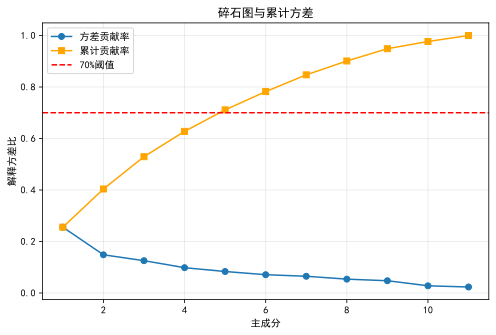

In [16]:
# 4. 碎石图
plt.figure(figsize = (8, 5))

plt.plot(range(1, len(features) + 1), variance, marker = 'o', label = '方差贡献率')
plt.plot(range(1, len(features) + 1), cum_variance, marker = 's', label = '累计贡献率', color = 'orange')
plt.axhline(y = 0.7, color = 'r', linestyle = '--', label = '70%阈值') # 画一条70%的参考线
plt.xlabel('主成分')
plt.ylabel('解释方差比')
plt.title('碎石图与累计方差')
plt.legend()
plt.grid(alpha = 0.3)
#plt.savefig("./figures_mcdonalds/碎石图.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

In [17]:
# 5. 根据累计贡献率选主成分数量
threshold = 0.7
n_components = np.argmax(cum_variance >= threshold) + 1 
print(f"累计贡献率达到 {threshold*100}% 时，保留的主成分数量为: {n_components} 个")

X_pca_selected = X_pca[:, :n_components]

# 将降维后的数据转换为DataFrame
pca_columns = [f'PC{i+1}' for i in range(n_components)]
X_pca_df = pd.DataFrame(X_pca_selected, columns = pca_columns, index = data.index)

# 将PCA结果合并回原数据（方便后续做聚类和画像分析）
data = pd.concat([data, X_pca_df], axis=1)

print(f"\n降维后的数据维度: {X_pca_df.shape}")
print("降维后的数据前5行:")
display(X_pca_df.head())

累计贡献率达到 70.0% 时，保留的主成分数量为: 5 个

降维后的数据维度: (1453, 5)
降维后的数据前5行:


,PC1,PC2,PC3,PC4,PC5
0,0.704334,-0.437016,0.268698,-0.872074,-1.521184
1,-0.467820,0.364277,-1.596835,-0.004835,0.462385
2,0.191986,1.712949,-0.339413,3.368168,-1.266802
3,-0.116991,-1.155122,-1.003913,0.469589,1.141750
4,-0.034724,-1.390267,0.792275,0.473031,-0.270488


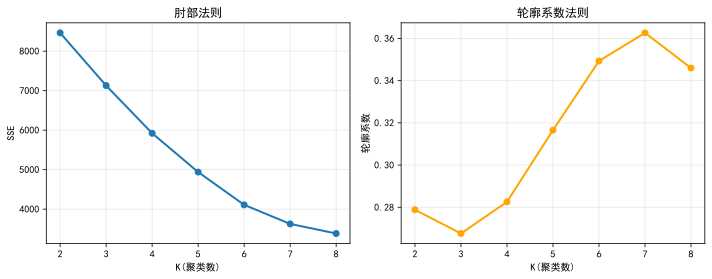

In [18]:
# Kmeans聚类
# 1. 确定K值
X_cluster = X_pca_selected

sse = []
silhouette = []
K = range(2, 9)

for k in K:
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = model.fit_predict(X_cluster)
    sse.append(model.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels))
    
plt.figure(figsize = (10, 4))

# 肘部法则
plt.subplot(1, 2, 1)
plt.plot(K, sse, marker = 'o', linewidth = 2)
plt.xticks(K)
plt.xlabel('K(聚类数)')
plt.ylabel('SSE')
plt.title('肘部法则')
plt.grid(alpha = 0.3)

# 轮廓系数
plt.subplot(1, 2, 2)
plt.plot(K, silhouette, marker = 'o', linewidth = 2, color = 'orange')
plt.xticks(K)
plt.xlabel('K(聚类数)')
plt.ylabel('轮廓系数')
plt.title('轮廓系数法则')
plt.grid(alpha = 0.3)

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/肘部法则和轮廓系数法则图.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

In [19]:
# 2. 建立模型
kmeans = KMeans(
    n_clusters = 5,
    random_state = 42,
    n_init = 10
)

data["Cluster"] = kmeans.fit_predict(X_cluster)

display(data[["Cluster"]].head())

,Cluster
0,1
1,4
2,0
3,4
4,1


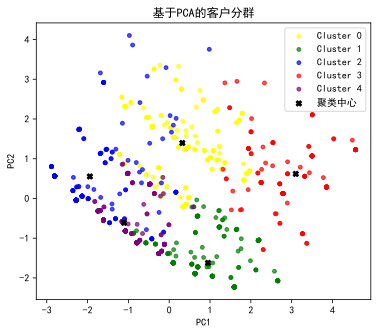

In [20]:
# 3. PCA二维聚类可视化
plt.figure(figsize = (6, 5))

colors = ['yellow', 'green', 'blue', 'red', 'purple']

for i in sorted(data["Cluster"].unique()):
    plt.scatter(
        data.loc[data["Cluster"] == i, "PC1"],
        data.loc[data["Cluster"] == i, "PC2"],
        s = 15,
        color = colors[i],
        alpha = 0.7,
        label = f"Cluster {i}"
    )

# 聚类中心（仅显示前两个主成分）
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c = "black",
    marker = "X",
    s = 30,
    label = "聚类中心"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("基于PCA的客户分群")
plt.legend()

#plt.savefig("./figures_mcdonalds/PCA二维聚类可视化.png", dpi = 300, bbox_inches = "tight")  # 保存图片
plt.show()

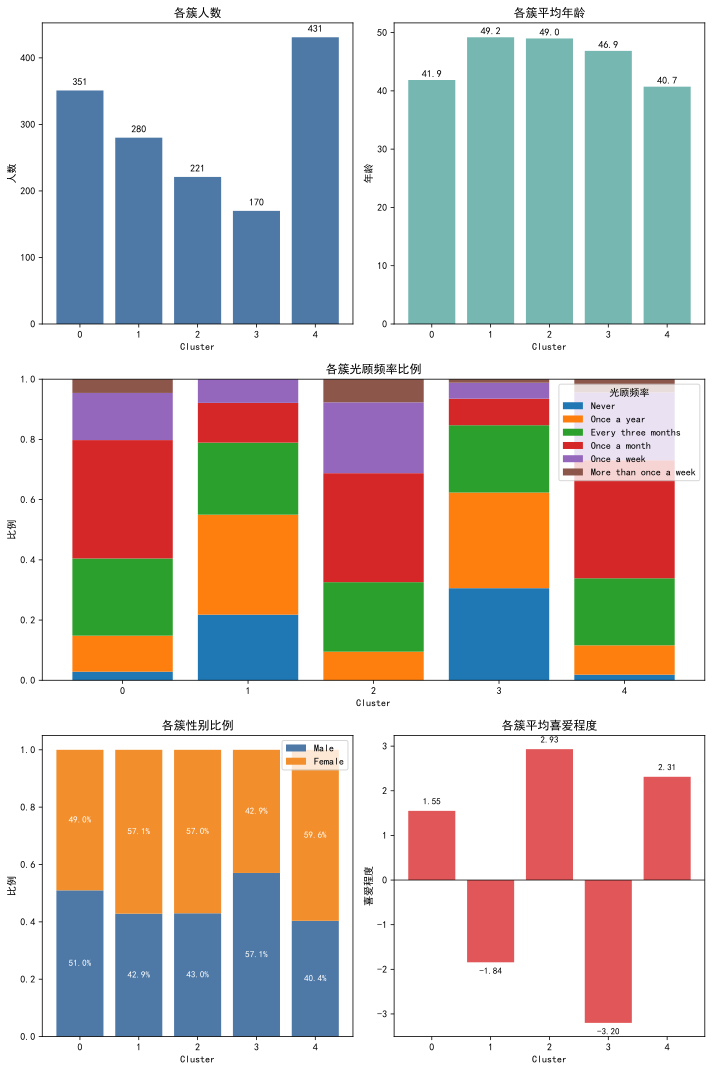

In [21]:
# 消费者画像分析
# 1. 数据准备
# 1.1群体人数
cluster_count = data["Cluster"].value_counts().sort_index()

# 1.2平均年龄
age_profile = data.groupby("Cluster")["Age"].mean()

# 1.3性别比例
gender_profile = pd.crosstab(data["Cluster"], data["Gender"], normalize = "index")

# 固定男女顺序
gender_profile = gender_profile[["Male", "Female"]]

# 1.4到店频率（按指定顺序）
visit_order = [
    "Never",
    "Once a year",
    "Every three months",
    "Once a month",
    "Once a week",
    "More than once a week"
]

visit_profile = pd.crosstab(data["Cluster"], data["VisitFrequency"], normalize = "index")
visit_profile = visit_profile.reindex(columns = visit_order)

# 1.5平均喜爱值
like_profile = data.groupby("Cluster")["like_int"].mean()

fig = plt.figure(figsize = (10, 15))

# 2. 可视化
# 2.1群体人数
ax1 = plt.subplot2grid((3, 2), (0, 0))

bars = ax1.bar(cluster_count.index, cluster_count.values, color = "#4E79A7")

ax1.set_title("各簇人数")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("人数")
ax1.set_xticks(cluster_count.index)

# 数值标注
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2,
             h+8,
             f"{int(h)}",
             ha = "center",
             fontsize = 10)

# 2.2平均年龄
ax2 = plt.subplot2grid((3, 2), (0, 1))

bars = ax2.bar(age_profile.index, age_profile.values, color = "#76B7B2")

ax2.set_title("各簇平均年龄")
ax2.set_xlabel("Cluster")
ax2.set_ylabel("年龄")
ax2.set_xticks(age_profile.index)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2,
             h+0.5,
             f"{h:.1f}",
             ha = "center",
             fontsize = 10)

# 2.3光顾频率
ax3 = plt.subplot2grid((3, 2), (1, 0), colspan = 2)

bottom = np.zeros(len(visit_profile))

for i, col in enumerate(visit_profile.columns):
    ax3.bar(
        visit_profile.index,
        visit_profile[col],
        bottom = bottom,
        label = col,
    )

    bottom += visit_profile[col].values

ax3.set_title("各簇光顾频率比例")
ax3.set_xlabel("Cluster")
ax3.set_ylabel("比例")
ax3.set_xticks(visit_profile.index)
ax3.legend(title = "光顾频率", loc = "upper right")

# 2.4性别
ax4 = plt.subplot2grid((3, 2), (2, 0))

male = gender_profile["Male"]
female = gender_profile["Female"]

bar1 = ax4.bar(gender_profile.index, male, label = "Male", color = "#4E79A7")
bar2 = ax4.bar(gender_profile.index, female, bottom = male, label = "Female", color = "#F28E2B")

ax4.set_title("各簇性别比例")
ax4.set_xlabel("Cluster")
ax4.set_ylabel("比例")
ax4.set_xticks(gender_profile.index)
ax4.legend(loc="upper right")

# 柱内百分比
for i in range(len(gender_profile)):
    ax4.text(i,
             male.iloc[i]/2,
             f"{male.iloc[i]*100:.1f}%",
             ha = "center",
             va = "center",
             color = "white",
             fontsize = 9)
    ax4.text(i,
             male.iloc[i]+female.iloc[i]/2,
             f"{female.iloc[i]*100:.1f}%",
             ha = "center",
             va = "center",
             color = "white",
             fontsize = 9)

# 2.5平均喜爱
ax5 = plt.subplot2grid((3, 2), (2, 1))

bars = ax5.bar(like_profile.index, like_profile.values, color="#E15759")

# y=0基准线
ax5.axhline(0, color = "black", linewidth = 0.7)

ax5.set_title("各簇平均喜爱程度")
ax5.set_xlabel("Cluster")
ax5.set_ylabel("喜爱程度")
ax5.set_xticks(like_profile.index)

# 正负值分别标注
for bar in bars:
    h = bar.get_height()
    if h >= 0:
        y = h + 0.12
        va = "bottom"
    else:
        y = h - 0.12
        va = "top"
    ax5.text(bar.get_x()+bar.get_width()/2,
             y,
             f"{h:.2f}",
             ha = "center",
             va = va,
             fontsize = 9)

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/消费者画像分析.svg", bbox_inches = "tight")  # 保存矢量图
plt.show()

In [22]:
# 热力图
# 1. 各群体感知变量均值
features = ["yummy_bin", "convenient_bin", "spicy_bin", "fattening_bin", "greasy_bin", "fast_bin", 
            "cheap_bin", "tasty_bin","expensive_bin", "healthy_bin", "disgusting_bin"]

cluster_profile = (data.groupby("Cluster")[features].mean().round(3))

display(cluster_profile)

,yummy_bin,convenient_bin,spicy_bin,fattening_bin,greasy_bin,fast_bin,cheap_bin,tasty_bin,expensive_bin,healthy_bin,disgusting_bin
Cluster,,,,,,,,,,,
0,0.701,0.986,0.131,0.957,0.593,0.889,0.077,0.798,0.923,0.168,0.142
1,0.014,0.904,0.104,0.975,0.654,0.986,0.893,0.111,0.046,0.054,0.486
2,0.819,0.964,0.113,0.308,0.032,0.937,0.796,0.887,0.113,0.778,0.023
3,0.018,0.476,0.076,0.906,0.759,0.559,0.088,0.053,0.871,0.029,0.829
4,0.856,0.988,0.053,0.995,0.552,0.970,0.933,0.974,0.023,0.088,0.049


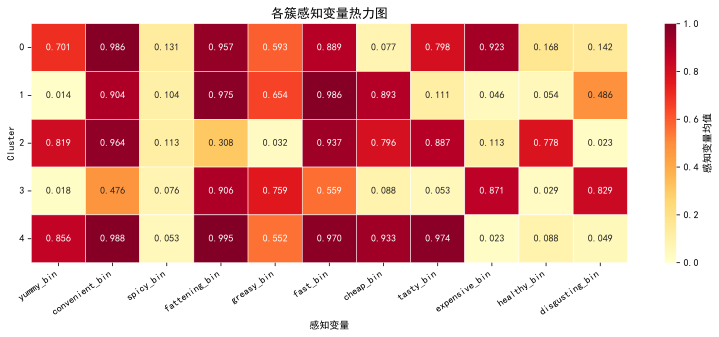

In [23]:
# 2. 可视化
plt.figure(figsize=(11, 4.8))

sns.heatmap(
    cluster_profile,
    annot = True,
    fmt = ".3f",
    cmap = "YlOrRd",
    linewidths = 0.5,
    linecolor = "white",
    vmin = 0,
    vmax = 1,
    cbar_kws = {"label":"感知变量均值"}
)

plt.title("各簇感知变量热力图", fontsize = 13)
plt.xlabel("感知变量")
plt.ylabel("Cluster")

plt.xticks(rotation = 35, ha = "right")
plt.yticks(rotation = 0)

plt.tight_layout()
#plt.savefig("./figures_mcdonalds/热力图.png", dpi = 300, bbox_inches = "tight")  # 保存图片
plt.show()

In [24]:
# 3. 各簇前3影响感知变量
top_features = {}

for c in cluster_profile.index:
    top3 = (cluster_profile.loc[c].sort_values(ascending = False).head(3))
    top_features[c] = list(top3.index)

summary = pd.DataFrame({
    "Cluster": list(top_features.keys()),
    "前3影响感知变量": [", ".join(v) for v in top_features.values()]
})

display(summary)

,Cluster,前3影响感知变量
0,0,"convenient_bin, fattening_bin, expensive_bin"
1,1,"fast_bin, fattening_bin, convenient_bin"
2,2,"convenient_bin, fast_bin, tasty_bin"
3,3,"fattening_bin, expensive_bin, disgusting_bin"
4,4,"fattening_bin, convenient_bin, tasty_bin"


In [25]:
# 4. 各簇用户画像简述
persona = pd.DataFrame({"人数": cluster_count, "平均年龄": age_profile.round(1), "喜爱程度": like_profile.round(2)})
persona["男 %"] = (gender_profile["Male"] * 100).round(1)
persona["女 %"] = (gender_profile["Female"] * 100).round(1)
display(persona)

,人数,平均年龄,喜爱程度,男 %,女 %
0,351,41.9,1.55,51.0,49.0
1,280,49.2,-1.84,42.9,57.1
2,221,49.0,2.93,43.0,57.0
3,170,46.9,-3.20,57.1,42.9
4,431,40.7,2.31,40.4,59.6
